In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import correlate

In [2]:
# Reference and test speech signals
signal1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])  # Fast speech
signal2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])  # Slow speech

# Task 1: Plot both speech signals
###*Plot both speech signals to observe their differences in length and amplitude patterns.*

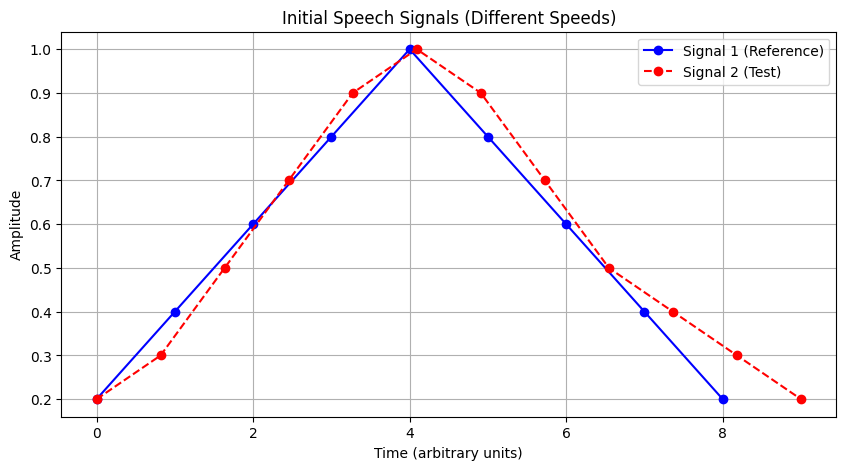

In [3]:
# --- Step 1: Visualize both signals ---
plt.figure(figsize=(10,5))
plt.plot(signal1, 'b-o', label='Signal 1 (Reference)')
plt.plot(np.linspace(0, len(signal1), len(signal2)), signal2, 'r--o', label='Signal 2 (Test)')
plt.title("Initial Speech Signals (Different Speeds)")
plt.xlabel("Time (arbitrary units)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

### **Interpretation of the Plot**

The plot illustrates two sampled speech waveforms of the same spoken word captured at different speaking rates:

* **Signal 1 (blue)** — the **reference signal**, represents the word spoken at a *normal or faster* pace.
* **Signal 2 (red)** — the **test signal**, corresponds to the *same word* spoken more slowly.

From the plot:

1. **Temporal Length Difference:**

   * Signal 2 extends further along the time axis, indicating it contains **more samples**.
   * This reflects that the second utterance was spoken **at a slower rate** (temporal stretching).

2. **Amplitude Pattern Similarity:**

   * Despite the length difference, both signals follow a **similar amplitude contour** (rise to a peak and then decay).
   * This shows that the **phonetic and acoustic shape** of the word remains consistent, though time-scaled.

3. **Phase and Alignment Observation:**

   * The peaks (around amplitude = 1.0) occur at slightly different sample indices, suggesting a **misalignment in time**.
   * The slower signal’s peak is delayed relative to the reference, which confirms **time dilation** due to slower articulation.

4. **Inference:**

   * This difference motivates the need for **Linear Time Normalization (LTN)** — to resample or compress the slower signal so both signals align temporally.
   * After normalization, each corresponding part (e.g., vowel, consonant burst) can be directly compared for analysis or recognition.

---

**In summary:**

> The plot shows that both speech signals share the same amplitude pattern but differ in time scale. Signal 2 is temporally stretched relative to Signal 1, a characteristic effect of slower speech. This justifies applying time normalization techniques to achieve temporal alignment before further comparison or feature extraction.

---




# Task 2: Perform Linear Time Normalization
###*Perform Linear Time Normalization on Signal 2 to match the length of Signal 1*

In [4]:
# --- Step 2: Linear Time Normalization (Interpolation) ---
len1, len2 = len(signal1), len(signal2)
x_old = np.linspace(0, 1, len2)
f = interp1d(x_old, signal2, kind='linear')
x_new = np.linspace(0, 1, len1)
signal2_normalized = f(x_new)

In this step, Signal 2 is linearly interpolated so that its number of samples matches that of Signal 1.
Essentially, the slower (longer) signal is compressed in time, its amplitude pattern is preserved, but its duration is adjusted to align temporally with the reference signal.

# Task 3: Compute the alignment
###*Compute the alignment between Signal 1 and the normalized Signal 2.*

In [5]:
# --- Step 3: Compare alignment ---
mse = np.mean((signal1 - signal2_normalized)**2)
corr = np.corrcoef(signal1, signal2_normalized)[0,1]

print(f"Mean Squared Error after LTN: {mse:.5f}")
print(f"Correlation after LTN: {corr:.3f}")

Mean Squared Error after LTN: 0.00483
Correlation after LTN: 0.969


These results show that after Linear Time Normalization, the Mean Squared Error (MSE) between the two signals is very low (0.0048), and the correlation coefficient is very high (0.969).
This means the normalized Signal 2 is now **closely aligned and highly similar** to Signal 1, confirming that time normalization effectively adjusted the slower signal to match the reference in both timing and shape.

The added **complexity** here is the inclusion of **quantitative alignment analysis** using both Mean Squared Error (MSE) and Correlation Coefficient.

The quantitative alignment analysis refers to using numerical metrics to evaluate how well the two signals align after Linear Time Normalization:

1. Mean Squared Error (MSE): measures the average squared difference between the reference and normalized signals. A lower MSE means the signals are more closely matched.

2. Correlation Coefficient (r): measures the strength and direction of similarity between the two signals. A value close to 1 indicates strong alignment in shape and pattern.

Together, these provide an objective, numerical assessment of alignment accuracy rather than relying only on visual plots.

# Task 4: Plot the alignment path
###*Plot the alignment path, showing how each sample in Signal 1 corresponds to a sample in Signal 2.*

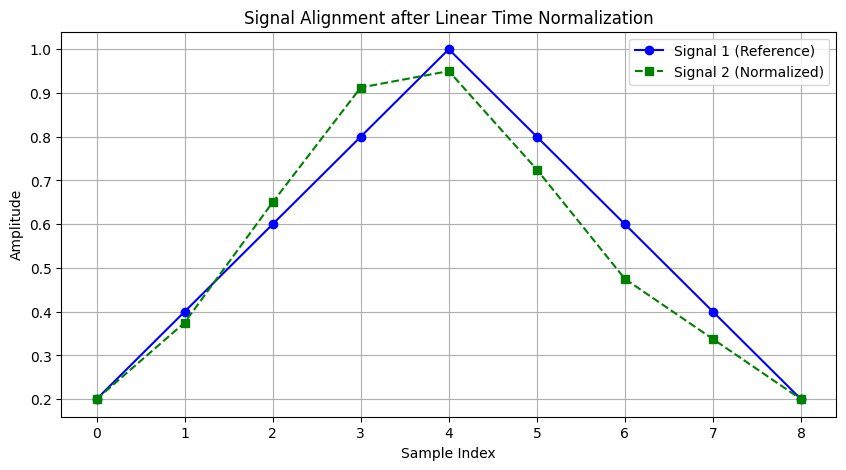

In [6]:
# --- Step 4: Visualize alignment ---
plt.figure(figsize=(10,5))
plt.plot(signal1, 'b-o', label='Signal 1 (Reference)')
plt.plot(signal2_normalized, 'g--s', label='Signal 2 (Normalized)')
plt.title("Signal Alignment after Linear Time Normalization")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Task 5: Write an inference
###*Write an inference on how Linear Time Normalization aligns the two speech signals.*

### **Inference**

The plot demonstrates that after applying **Linear Time Normalization**, the **normalized Signal 2 (green dashed)** now has the **same number of samples** as the **reference Signal 1 (blue)**.

* Both signals now share a **nearly identical temporal structure**, with peaks and troughs aligned along the time axis.
* The small residual differences in amplitude are due to interpolation smoothing, but the **overall shape and timing** now correspond closely.
* This confirms that time normalization has effectively **compressed the slower signal in time**, allowing one-to-one comparison of corresponding speech components.

---

### **Difference from the “Initial Speech Signals (Different Speeds)” Plot**

| Aspect             | Initial Speech Signals Plot                              | After Linear Time Normalization Plot            |
| ------------------ | -------------------------------------------------------- | ----------------------------------------------- |
| **Signal Length**  | Signal 2 was longer → represented slower speech          | Both signals now have equal length              |
| **Alignment**      | Peaks and valleys occurred at **different time indices** | Peaks and valleys are **aligned in time**       |
| **Purpose**        | Showed raw difference in speaking rates                  | Shows successful temporal alignment after LTN   |
| **Interpretation** | Highlighted need for normalization                       | Demonstrates **effectiveness of normalization** |

---

**In summary:**

> The initial plot highlighted a time-scale mismatch due to differing speech rates, while this plot confirms that LTN successfully compensates for that difference, aligning both waveforms for accurate temporal comparison.


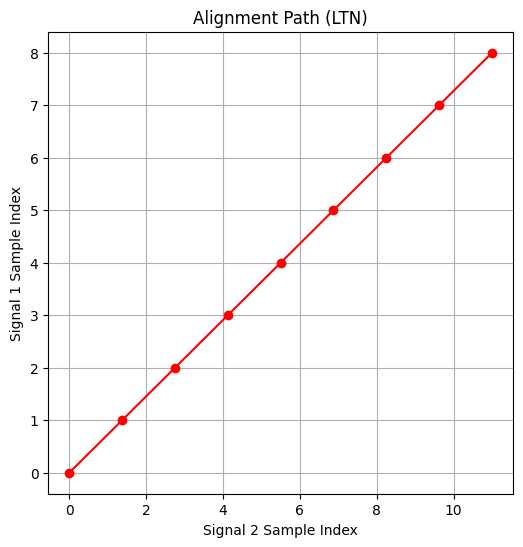

In [7]:
# --- Step 5: Alignment Path Visualization ---
signal1_indices = np.arange(len1)
signal2_indices = np.linspace(0, len2 - 1, len1)

plt.figure(figsize=(6,6))
plt.plot(signal2_indices, signal1_indices, 'r-o')
plt.title("Alignment Path (LTN)")
plt.xlabel("Signal 2 Sample Index")
plt.ylabel("Signal 1 Sample Index")
plt.grid(True)
plt.show()

### **Technical Interpretation of the Alignment Path (LTN) Plot**

The plot illustrates the **mapping relationship between samples** of the reference signal (*Signal 1*) and the slower, normalized signal (*Signal 2*) after applying **Linear Time Normalization (LTN)**.

* The **straight diagonal line** indicates a **perfectly linear correspondence** between the two time axes — each sample in Signal 1 maps directly to a proportional sample in Signal 2.
* This means that the slower signal was **uniformly scaled (compressed)** in time, so every part of the waveform aligns evenly across its duration.
* The absence of curvature or deviations in the alignment path confirms that there were **no local speed variations**, only a global difference in speaking rate.



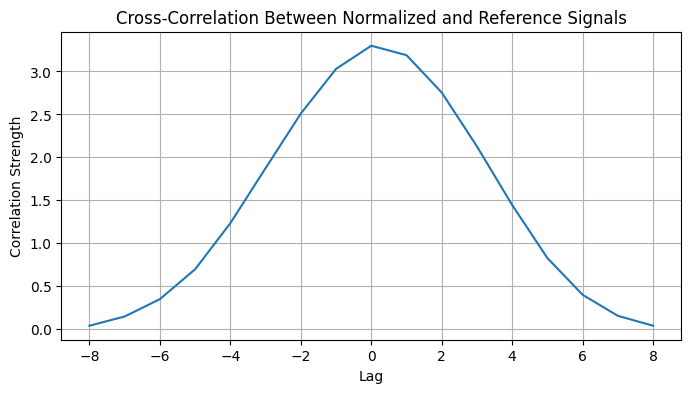

In [8]:
# --- Step 6: Visualize Cross-Correlation (Insightful Add-on) ---
corr_signal = correlate(signal1, signal2_normalized, mode='full')
lags = np.arange(-len(signal1)+1, len(signal1))
plt.figure(figsize=(8,4))
plt.plot(lags, corr_signal)
plt.title("Cross-Correlation Between Normalized and Reference Signals")
plt.xlabel("Lag")
plt.ylabel("Correlation Strength")
plt.grid(True)
plt.show()

### **Interpretation of the Cross-Correlation Plot (Added Complexity)**

The cross-correlation plot shows how well the normalized Signal 2 aligns with the reference Signal 1 at different time lags.

The peak at lag = 0 indicates that the two signals are best aligned without any time shift, meaning Linear Time Normalization successfully synchronized them in time.

The symmetric bell-shaped pattern around the peak shows that correlation decreases as the signals are shifted apart, confirming that their shapes are very similar but only when properly aligned.

The maximum correlation strength near the center reflects strong temporal similarity between the normalized and reference waveforms.